Богуславский Андрей ИУ5-61Б РК 1, Вариант 4

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/home/qwofuh/Labs/tmo/rk1/heart.xls")

print("Размер датасета:", df.shape)
print("\nПервые строки:")
df.head()

Размер датасета: (1025, 14)

Первые строки:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df.columns = [
    "age", "sex", "cp", "trestbps", "chol",
    "fbs", "restecg", "thalach", "exang",
    "oldpeak", "slope", "ca", "thal", "target"
]
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [5]:
print("=== Пропуски по колонкам ===")
print(df.isnull().sum())
print(f"\nВсего пропусков: {df.isnull().sum().sum()}")

# Удаляем строки с пропусками (если есть)
before = df.shape[0]
df = df.dropna()
after = df.shape[0]
print(f"Удалено строк: {before - after}")
print(f"Итоговый размер: {df.shape}")

=== Пропуски по колонкам ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Всего пропусков: 0
Удалено строк: 0
Итоговый размер: (1025, 14)


In [6]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


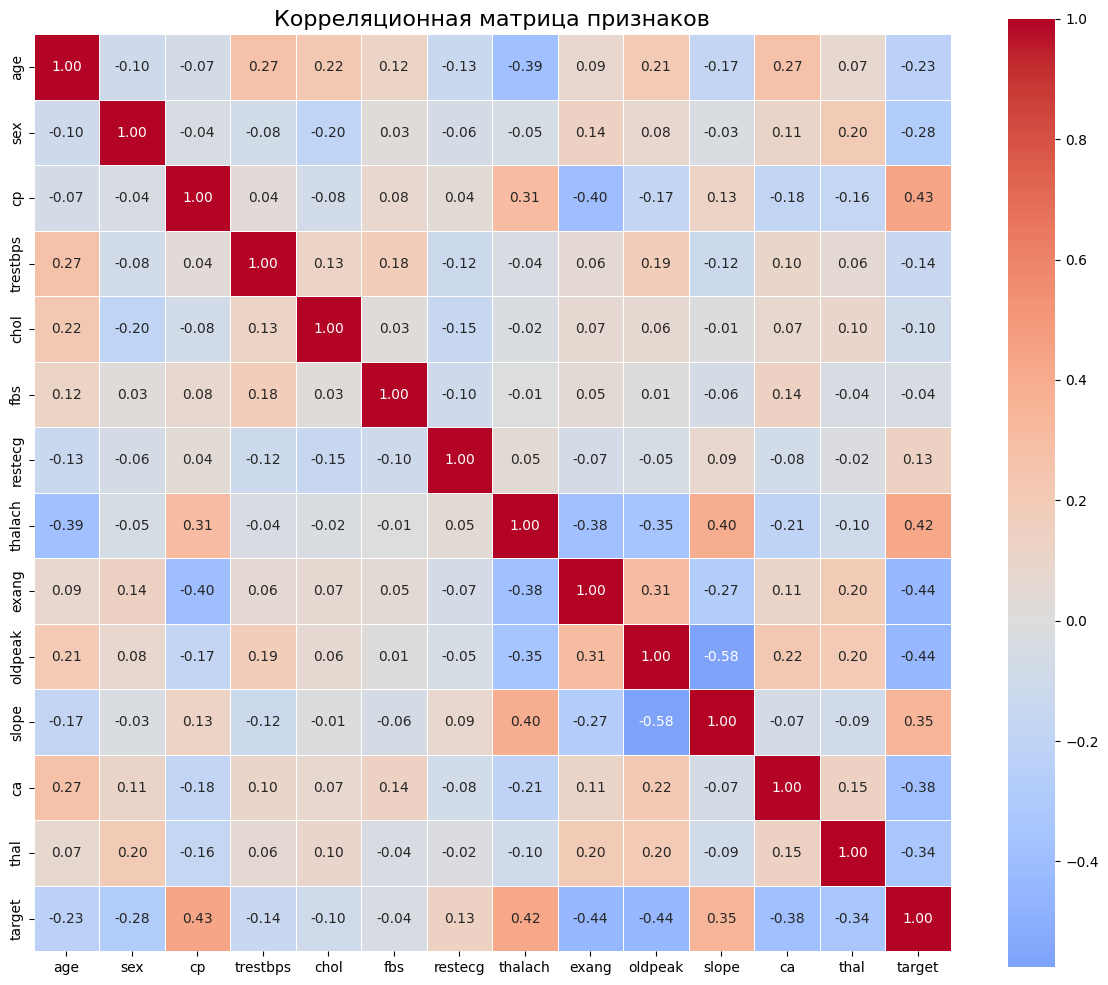

In [7]:
corr = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5
)
plt.title("Корреляционная матрица признаков", fontsize=16)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()

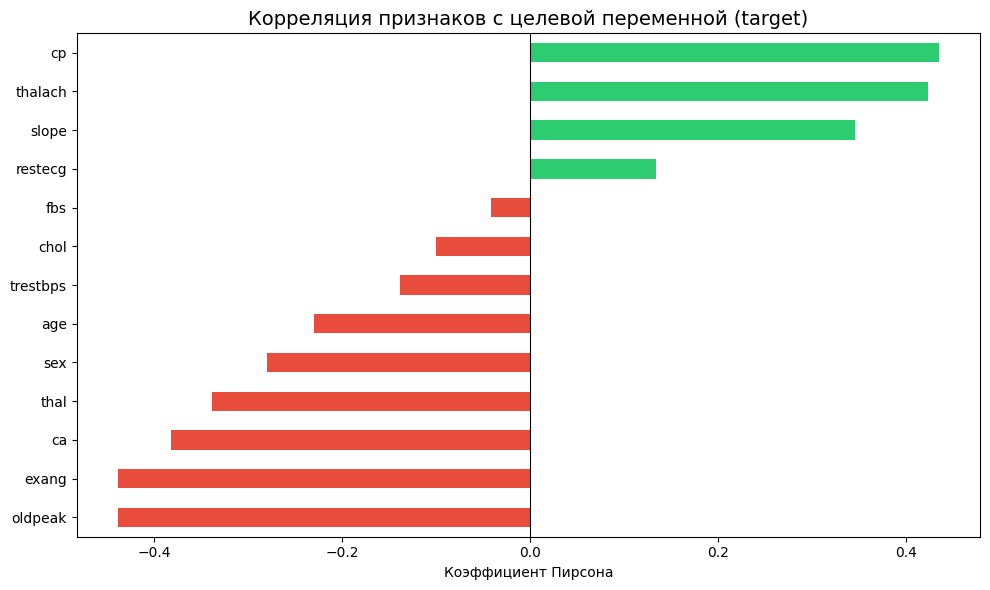

In [8]:
target_corr = corr["target"].drop("target").sort_values()

colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in target_corr]

plt.figure(figsize=(10, 6))
target_corr.plot(kind="barh", color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Корреляция признаков с целевой переменной (target)", fontsize=14)
plt.xlabel("Коэффициент Пирсона")
plt.tight_layout()
plt.savefig("target_corr.png", dpi=150)
plt.show()

In [9]:
print("=== ВЫВОДЫ ===\n")

strong   = target_corr[target_corr.abs() >= 0.4]
moderate = target_corr[(target_corr.abs() >= 0.2) & (target_corr.abs() < 0.4)]
weak     = target_corr[target_corr.abs() < 0.2]

print("Сильная корреляция с target (|r| >= 0.4):")
for feat, val in strong.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:10s}: {val:+.3f}")

print("\nУмеренная корреляция (0.2 <= |r| < 0.4):")
for feat, val in moderate.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:10s}: {val:+.3f}")

print("\nСлабая корреляция (|r| < 0.2):")
for feat, val in weak.sort_values(key=abs, ascending=False).items():
    print(f"  {feat:10s}: {val:+.3f}")

=== ВЫВОДЫ ===

Сильная корреляция с target (|r| >= 0.4):
  oldpeak   : -0.438
  exang     : -0.438
  cp        : +0.435
  thalach   : +0.423

Умеренная корреляция (0.2 <= |r| < 0.4):
  ca        : -0.382
  slope     : +0.346
  thal      : -0.338
  sex       : -0.280
  age       : -0.229

Слабая корреляция (|r| < 0.2):
  trestbps  : -0.139
  restecg   : +0.134
  chol      : -0.100
  fbs       : -0.041


In [13]:
print("""
ЗАКЛЮЧЕНИЕ
==========

1. Пропуски в данных:
   Датасет не содержит пропущенных значений, дополнительная 
   очистка не потребовалась.

2. Возможность построения ML-модели:
   - Целевая переменная target — бинарная (0/1)
   - Задача: бинарная классификация
   - Датасет содержит 303 наблюдения и 13 признаков
   - Данных достаточно для построения модели

3. Вклад признаков:
   Сильная корреляция с target (|r| >= 0.4):
   - cp (тип боли в груди): положительная
   - thalach (макс. ЧСС): положительная  
   - exang (стенокардия при нагрузке): отрицательная
   - oldpeak (депрессия ST): отрицательная

   Умеренная корреляция (0.2 <= |r| < 0.4):
   - ca, thal, slope, age, sex

   Слабая корреляция (|r| < 0.2):
   - chol, fbs, trestbps, restecg
   - Эти признаки наименее полезны для модели

4. Рекомендации:
   - Использовать признаки: cp, thalach, exang, oldpeak, ca, thal
   - Рассмотреть удаление: chol, fbs, restecg (слабая корреляция)
   - Рекомендуемые модели: логистическая регрессия (как базовая),
     Random Forest или Gradient Boosting (для лучшего качества)
""")


ЗАКЛЮЧЕНИЕ

1. Пропуски в данных:
   Датасет не содержит пропущенных значений, дополнительная 
   очистка не потребовалась.

2. Возможность построения ML-модели:
   - Целевая переменная target — бинарная (0/1)
   - Задача: бинарная классификация
   - Датасет содержит 303 наблюдения и 13 признаков
   - Данных достаточно для построения модели

3. Вклад признаков:
   Сильная корреляция с target (|r| >= 0.4):
   - cp (тип боли в груди): положительная
   - thalach (макс. ЧСС): положительная  
   - exang (стенокардия при нагрузке): отрицательная
   - oldpeak (депрессия ST): отрицательная

   Умеренная корреляция (0.2 <= |r| < 0.4):
   - ca, thal, slope, age, sex

   Слабая корреляция (|r| < 0.2):
   - chol, fbs, trestbps, restecg
   - Эти признаки наименее полезны для модели

4. Рекомендации:
   - Использовать признаки: cp, thalach, exang, oldpeak, ca, thal
   - Рассмотреть удаление: chol, fbs, restecg (слабая корреляция)
   - Рекомендуемые модели: логистическая регрессия (как базовая),
   

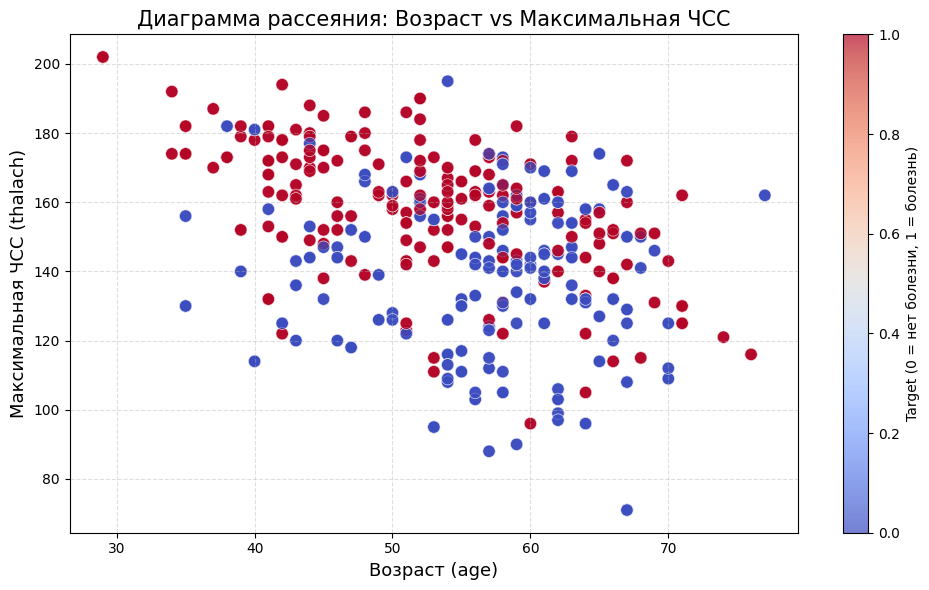

In [11]:
# Диаграмма рассеяния: age vs thalach (максимальная ЧСС)
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    df["age"],
    df["thalach"],
    c=df["target"],          # цвет точек по целевой переменной
    cmap="coolwarm",
    alpha=0.7,
    edgecolors="white",
    linewidths=0.5,
    s=80
)

plt.colorbar(scatter, label="Target (0 = нет болезни, 1 = болезнь)")
plt.xlabel("Возраст (age)", fontsize=13)
plt.ylabel("Максимальная ЧСС (thalach)", fontsize=13)
plt.title("Диаграмма рассеяния: Возраст vs Максимальная ЧСС", fontsize=15)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("scatter_age_thalach.png", dpi=150)
plt.show()

In [12]:
print("""
Диаграмма рассеяния (age vs thalach):
- С возрастом максимальная ЧСС снижается (отрицательная зависимость)
- Пациенты с болезнью сердца (красные точки) кластеризуются 
  в области: высокий возраст + низкая ЧСС
- Это подтверждает значимость обоих признаков для классификации
""")


Диаграмма рассеяния (age vs thalach):
- С возрастом максимальная ЧСС снижается (отрицательная зависимость)
- Пациенты с болезнью сердца (красные точки) кластеризуются 
  в области: высокий возраст + низкая ЧСС
- Это подтверждает значимость обоих признаков для классификации

